**Objective**

The objective of this project is to build a Simple Linear Regression model that predicts employee salary based on years of experience using Python and Scikit-learn.

In [14]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

**Step 1: Connect Google Drive**

The dataset is stored in Google Drive. We first mount Google Drive so that the notebook can access the dataset.

In [15]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Step 2: Load Dataset**

The dataset contains two columns:

Experience_Years (Independent Variable)
Monthly_Salary_PKR (Dependent Variable)

In [16]:
df = pd.read_excel(
    "/content/drive/MyDrive/Datasets/PK Salary Dataset.xlsx"
)

df.head()

,Experience_Years,Monthly_Salary_PKR
0,1,40000
1,2,50000
2,3,65000
3,4,80000
4,5,100000


**Step 3: Dataset Exploration**

Before training the model, we examine the dataset structure, statistics, and check for missing values.

In [17]:
print("Dataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape:
(8, 2)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Experience_Years    8 non-null      int64
 1   Monthly_Salary_PKR  8 non-null      int64
dtypes: int64(2)
memory usage: 260.0 bytes
None

Missing Values:
Experience_Years      0
Monthly_Salary_PKR    0
dtype: int64

Statistical Summary:


,Experience_Years,Monthly_Salary_PKR
count,8.00000,8.00000
mean,4.50000,94375.00000
std,2.44949,43213.54781
min,1.00000,40000.00000
25%,2.75000,61250.00000
50%,4.50000,90000.00000
75%,6.25000,125000.00000
max,8.00000,160000.00000


**Step 4: Data Visualization**

A scatter plot is created to visualize the relationship between experience and salary.

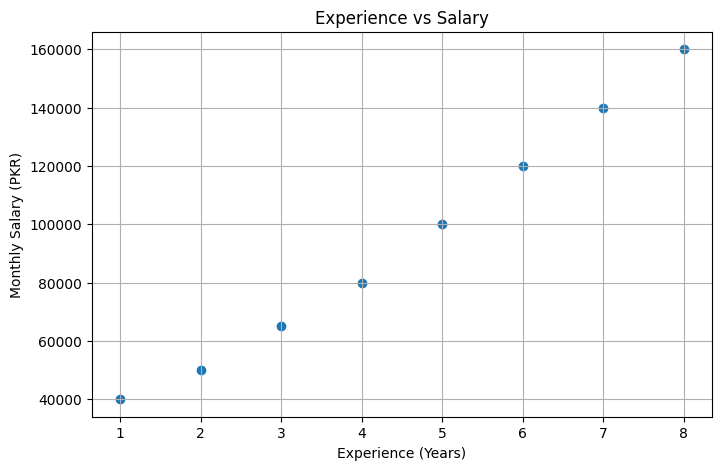

In [18]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Experience_Years"],
    df["Monthly_Salary_PKR"]
)

plt.title("Experience vs Salary")
plt.xlabel("Experience (Years)")
plt.ylabel("Monthly Salary (PKR)")
plt.grid(True)

plt.show()

**Step 5: Define Features and Target Variable**

The independent variable (X) is Experience_Years and the dependent variable (Y) is Monthly_Salary_PKR.

In [19]:
X = df[["Experience_Years"]]
y = df["Monthly_Salary_PKR"]

print(X.head())
print(y.head())

   Experience_Years
0                 1
1                 2
2                 3
3                 4
4                 5
0     40000
1     50000
2     65000
3     80000
4    100000
Name: Monthly_Salary_PKR, dtype: int64


**Step 6: Split Dataset into Training and Testing Sets**

The dataset is divided into 80% training data and 20% testing data.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Records:", len(X_train))
print("Testing Records:", len(X_test))

Training Records: 6
Testing Records: 2


**Step 7: Train the Linear Regression Model**

The model learns the relationship between experience and salary using the training data.

In [21]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Training Completed Successfully")

Model Training Completed Successfully


**Step 8: Display Model Equation**

The regression equation follows:

**Salary = m × Experience + b**

Where:

m = coefficient (slope)
b = intercept

In [22]:
print("Coefficient:", model.coef_[0])

print("Intercept:", model.intercept_)

print(
    f"\nSalary = {model.coef_[0]:.2f} × Experience + {model.intercept_:.2f}"
)

Coefficient: 17549.999999999993
Intercept: 15600.00000000003

Salary = 17550.00 × Experience + 15600.00


**Step 9: Predict Salaries**

The trained model is used to predict salaries for different years of experience.

In [23]:
salary_5 = model.predict([[5]])
salary_10 = model.predict([[10]])

print("Predicted Salary for 5 Years Experience:")
print(salary_5[0])

print()

print("Predicted Salary for 10 Years Experience:")
print(salary_10[0])

Predicted Salary for 5 Years Experience:
103350.0

Predicted Salary for 10 Years Experience:
191099.99999999997


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


**Step 10: Evaluate Model Performance**

Several metrics are used to evaluate model performance:

- R² Score
- MAE
- MSE
- RMSE






In [24]:
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

print("R² Score :", r2)
print("MAE      :", mae)
print("MSE      :", mse)
print("RMSE     :", rmse)

R² Score : 0.9994693877551021
MAE      : 800.0
MSE      : 649999.9999999971
RMSE     : 806.2257748298532


**Step 11: Plot Regression Line**

The regression line shows how the model fits the dataset.

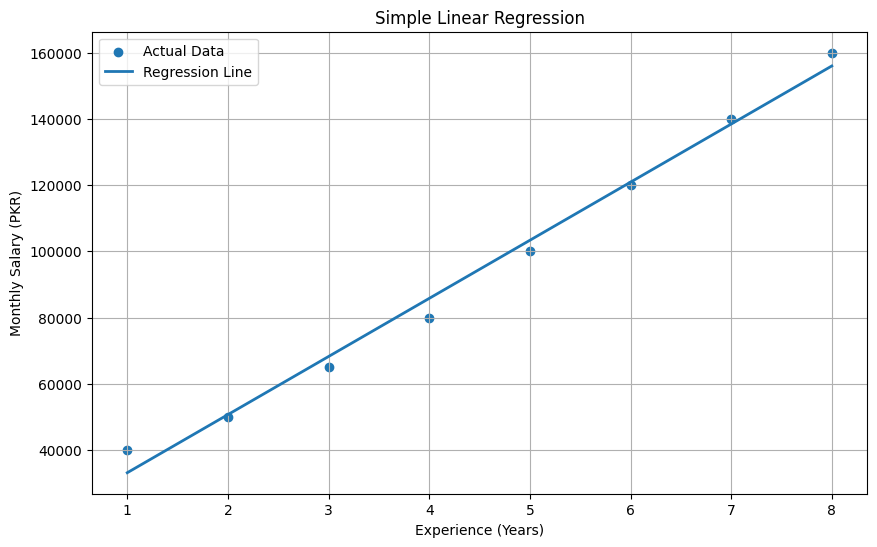

In [25]:
plt.figure(figsize=(10,6))

plt.scatter(
    X,
    y,
    label="Actual Data"
)

plt.plot(
    X,
    model.predict(X),
    linewidth=2,
    label="Regression Line"
)

plt.title("Simple Linear Regression")
plt.xlabel("Experience (Years)")
plt.ylabel("Monthly Salary (PKR)")

plt.legend()
plt.grid(True)

plt.show()

**Step 12: Future Salary Predictions**

The model predicts salaries for various experience levels.

In [26]:
future_data = pd.DataFrame({
    "Experience_Years":[2,4,6,8,10,12]
})

future_data["Predicted_Salary"] = model.predict(
    future_data
)

future_data

,Experience_Years,Predicted_Salary
0,2,50700.0
1,4,85800.0
2,6,120900.0
3,8,156000.0
4,10,191100.0
5,12,226200.0
